In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [2]:
X_test = pd.read_csv("../../data/processed/X_test.csv")
y_test = pd.read_csv("../../data/processed/y_test.csv").squeeze()

print("Shape X_test:", X_test.shape)
print("Shape y_test:", y_test.shape)

Shape X_test: (9043, 51)
Shape y_test: (9043,)


In [4]:
log_model = joblib.load("../../models/logistic_regression/logistic_regression.pkl")
rf_model  = joblib.load("../../models/random_forest/random_forest.pkl")
svm_model = joblib.load("../../models/svm/svm_model.pkl")
xgb_model = joblib.load("../../models/xgboost/xgb_baseline.pkl")

print("Modelos base cargados correctamente")

Modelos base cargados correctamente


In [5]:
def evaluate_model(model, X, y):
    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)[:, 1]
    else:
        y_prob = None

    metrics = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1-score": f1_score(y, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, y_prob) if y_prob is not None else np.nan
    }

    return metrics, y_pred, y_prob

In [7]:
results = {}

results["Logistic Regression"], y_pred_log, y_prob_log = evaluate_model(log_model, X_test, y_test)
results["Random Forest"], y_pred_rf, y_prob_rf = evaluate_model(rf_model, X_test, y_test)
results["SVM"], y_pred_svm, y_prob_svm = evaluate_model(svm_model, X_test, y_test)
results["XGBoost"], y_pred_xgb, y_prob_xgb = evaluate_model(xgb_model["model"], X_test, y_test)

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="F1-score", ascending=False)

results_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC
XGBoost,0.891408,0.568592,0.297732,0.390819,0.791744
Random Forest,0.884220,0.508346,0.316635,0.390215,0.783327
Logistic Regression,0.745660,0.260232,0.637051,0.369518,0.767464
SVM,0.842641,0.304394,0.268431,0.285284,0.650741


In [8]:
display(results_df.style.background_gradient(cmap="Greens"))

,Accuracy,Precision,Recall,F1-score,ROC-AUC
XGBoost,0.891408,0.568592,0.297732,0.390819,0.791744
Random Forest,0.884220,0.508346,0.316635,0.390215,0.783327
Logistic Regression,0.745660,0.260232,0.637051,0.369518,0.767464
SVM,0.842641,0.304394,0.268431,0.285284,0.650741


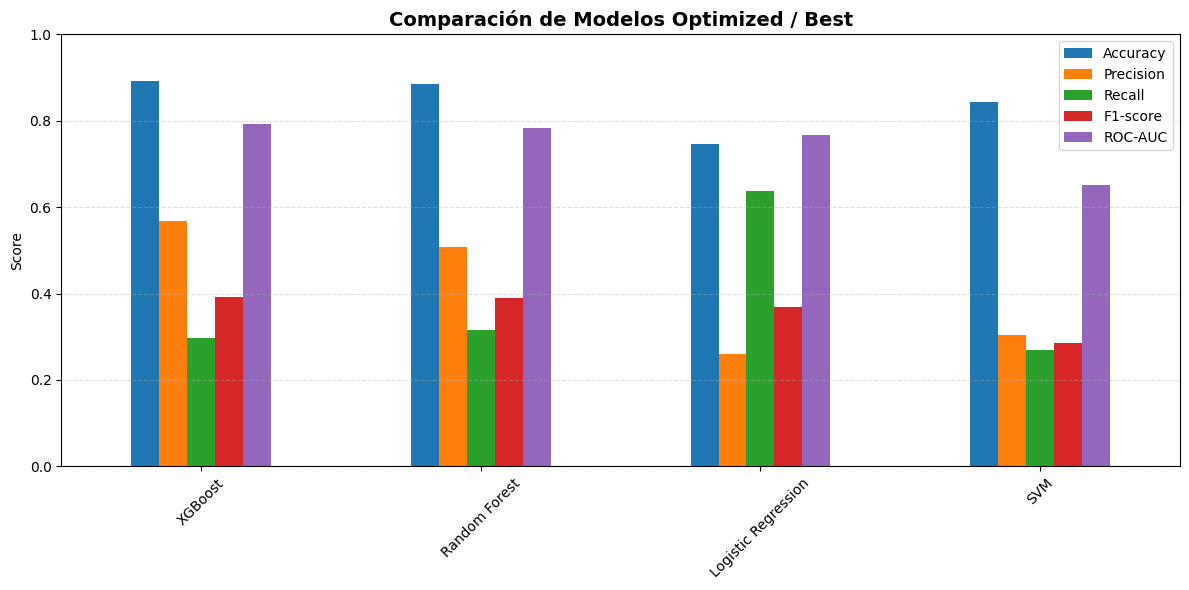

In [9]:
results_df.plot(kind="bar", figsize=(12, 6))
plt.title("Comparación de Modelos Optimized / Best", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

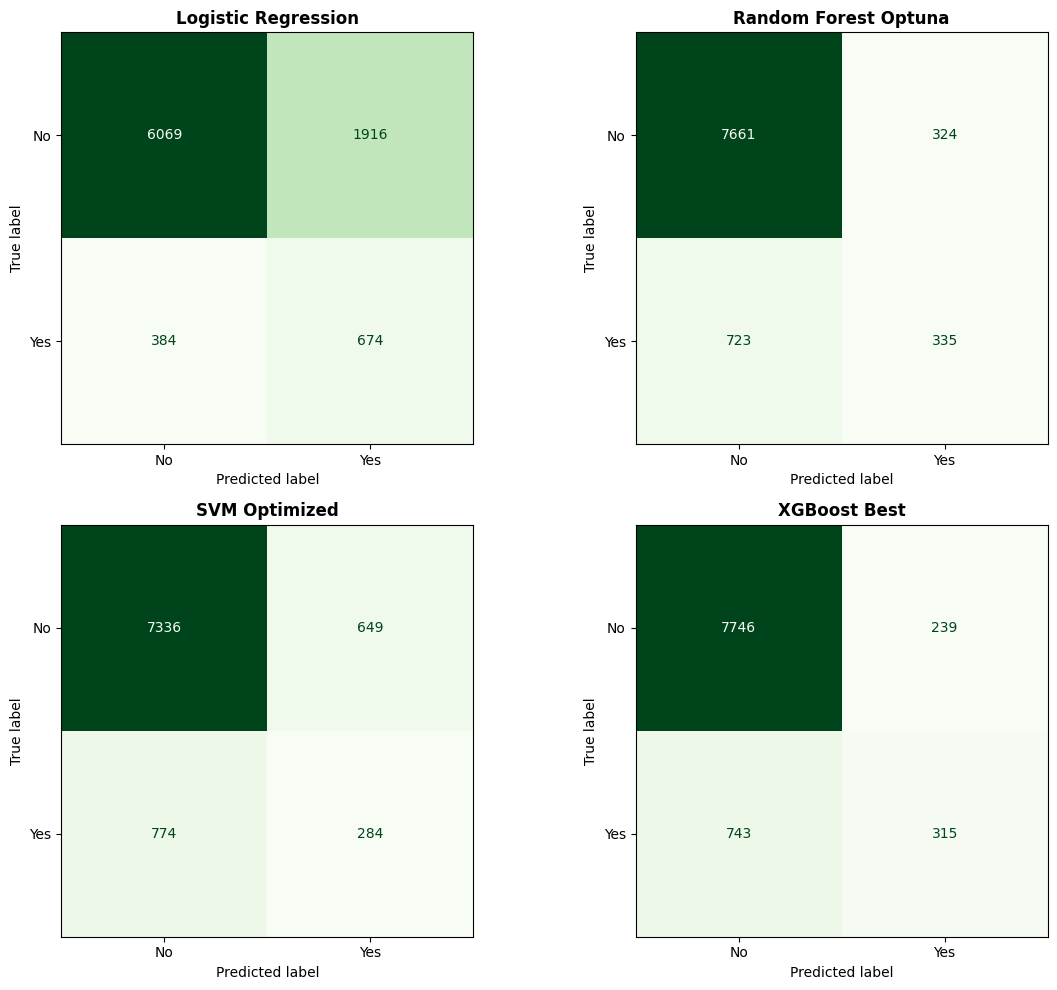

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_preds = {
    "Logistic Regression": y_pred_log,
    "Random Forest Optuna": y_pred_rf,
    "SVM Optimized": y_pred_svm,
    "XGBoost Best": y_pred_xgb
}

for ax, (name, y_pred) in zip(axes.flat, models_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, cmap="Greens", colorbar=False)
    ax.set_title(name, fontweight="bold")

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

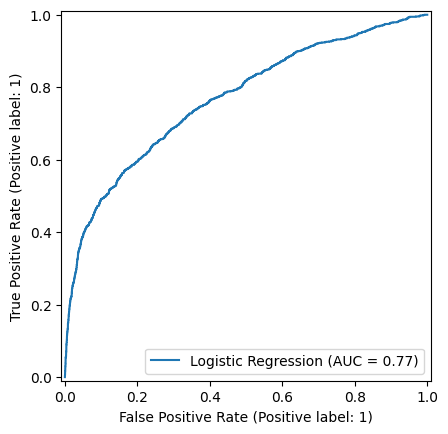

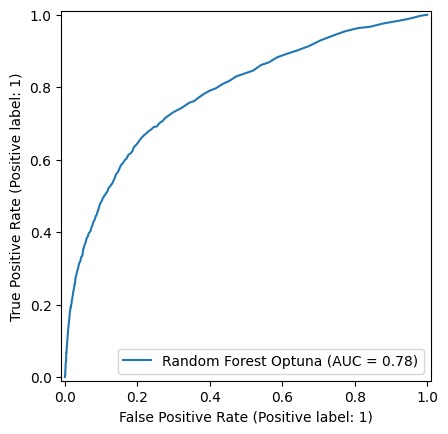

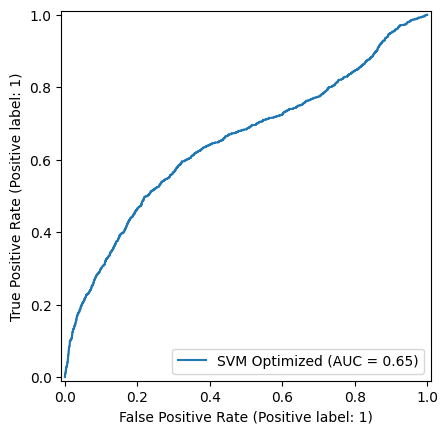

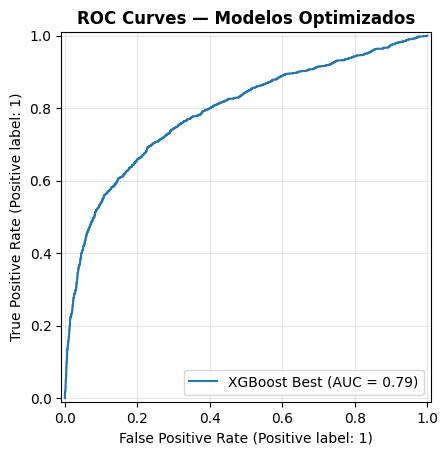

In [11]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_prob_log, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest Optuna")
RocCurveDisplay.from_predictions(y_test, y_prob_svm, name="SVM Optimized")
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost Best")

plt.title("ROC Curves — Modelos Optimizados", fontweight="bold")
plt.grid(alpha=0.3)
plt.show()

In [12]:
results_df.to_csv("../../data/db/model_comparison_optimized.csv", index=True)
print(" Resultados guardados en ../../data/db/model_comparison_optimized.csv")

 Resultados guardados en ../../data/db/model_comparison_optimized.csv


## Conclusión — Comparación de Modelos Optimizados

En esta etapa se compararon las versiones optimizadas de los modelos de clasificación.

Se observó el rendimiento de Logistic Regression, Random Forest optimizado con Optuna, SVM optimizado y XGBoost optimizado, utilizando el conjunto de prueba y métricas apropiadas para clasificación desbalanceada.

El modelo con mejor desempeño general será seleccionado como modelo final del proyecto, considerando especialmente F1-score y ROC-AUC, dado el desbalance de clases del dataset.